In [9]:
from herbie import Herbie
import pandas as pd, numpy as np, xarray as xr
import matplotlib.pyplot as plt

import numpy as np

In [13]:
ds2 = xr.open_dataset('ecmwf_2026032300.nc') #dataset for multiple runs

sh: 1: getfattr: not found


In [14]:
ds2

<xarray.Dataset> Size: 80kB
Dimensions:            (valid_time: 15, latitude: 11, longitude: 24)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 120B 2026-03-23 ... 2026-0...
  * latitude           (latitude) float64 88B 42.25 42.0 41.75 ... 40.0 39.75
  * longitude          (longitude) float64 192B -80.5 -80.25 ... -75.0 -74.75
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 120B ...
    heightAboveGround  (valid_time) float64 120B ...
    surface            float64 8B ...
Data variables:
    d2m                (valid_time, latitude, longitude) float32 16kB ...
    tp                 (valid_time, latitude, longitude) float32 16kB ...
    sf                 (valid_time, latitude, longitude) float32 16kB ...
    t2m                (valid_time, latitude, longitude) float32 16kB ...
    fg10               (valid_time, latitude, longitude) float32 16kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-31T08:32 GRIB to CDM+CF via cfgrib-0.9.1...

In [15]:
temp_f = (ds2['t2m'].values - 273.15)*(9/5) + 32 #temp K to F
snow= (ds2['sf'].values)*10 #10 inches of snow typically equals about 1 inch of water
wind_gust=(ds2['fg10'].values)*2.2369 #into mph
precip=(ds2['tp'].values)*39.37 #precip m to inches
dew_f=(ds2['d2m'].values - 273.15)*(9/5) + 32 #dewpoint K to F
lats = ds2['latitude'].values #latitude
lons = ds2['longitude'].values #longitude

In [16]:
temp_f_2d = temp_f[0, :, :] #finding each variable for each time step
dew_f_2d=dew_f[0,:,:]
precip_2d=precip[1,:,:]
snow_2d=snow[0,:,:]
wind_gust_2d=wind_gust[1,:,:]
wind_gust_2d

array([[24.174425 , 27.896767 , 25.091904 , 21.467863 , 18.103775 ,
        20.436792 , 19.916887 , 20.213976 , 22.238981 , 21.408882 ,
        17.756445 , 19.005962 , 17.140425 , 18.486057 , 19.960577 ,
        18.095037 , 17.417852 , 14.543086 , 13.992599 , 12.719051 ,
        13.254247 , 12.876333 , 12.926576 , 17.000618 ],
       [19.250624 , 19.92781  , 14.894786 , 16.764694 , 17.673435 ,
        16.511295 , 17.286783 , 20.211792 , 17.046492 , 18.510088 ,
        17.854746 , 17.826347 , 19.228779 , 17.07052  , 17.042122 ,
        16.096247 , 15.399399 , 17.33921  , 15.111049 , 12.935314 ,
        13.437742 , 14.4426   , 15.541389 , 15.882168 ],
       [17.898436 , 16.179256 , 16.70353  , 16.214207 , 16.231684 ,
        15.148185 , 14.667601 , 17.433144 , 16.51348  , 13.815657 ,
        18.571253 , 21.054998 , 20.321014 , 20.207422 , 18.073193 ,
        16.323431 , 13.920511 , 11.117832 , 13.972939 , 15.207166 ,
        17.203773 , 14.737504 , 11.441134 , 10.910308 ],
       [16.57

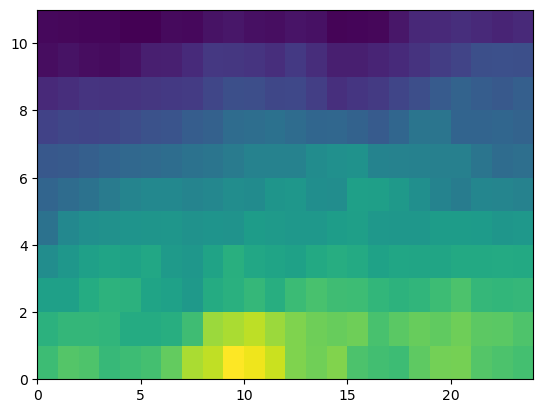

In [18]:
plt.pcolormesh(np.flipud(temp_f_2d)) #pcolormesh plot of temperature hazards

In [19]:
temp_f.max()

np.float32(nan)

In [20]:
#Relavtive Humidity Def: 
def calc_rh(temp_f_2d, dew_f_2d):
    return 100 * np.exp((17.625 * dew_f_2d)/(243.04 + dew_f_2d)) / np.exp((17.625 * temp_f_2d)/(243.04 + temp_f_2d))
RH = calc_rh(temp_f_2d, dew_f_2d)
#Wet Bulb Def: 
def wet_bulb_temp(temp_f_2d, RH):
    return temp_f_2d * np.arctan(0.151977 * (RH + 8.313659)**0.5) + \
           np.arctan(temp_f_2d + RH) - np.arctan(RH - 1.676331) + \
           0.00391838 * RH**1.5 * np.arctan(0.023101 * RH) - 4.686035
Tw = wet_bulb_temp(temp_f_2d, RH)
def wbgt_calc(temp_f_2d, Tw):
    return 0.7 * Tw + 0.3 * temp_f_2d

WBGT = wbgt_calc(temp_f_2d, Tw) #wet bulb globe temperature, which is found from the above functions


In [21]:
# For games its either we are playing or not, could do a very tight gradient where the parameter lies, say 25 is the yes no mark have like 30 be 70 percent
# Start with all contributions set to 0
temp_contribution = np.zeros_like(temp_f_2d)

# 80 <= T < 90 : linear increase from 0 to 1
mask = (temp_f_2d >= 80) & (temp_f_2d < 90)
temp_contribution[mask] = (temp_f_2d[mask] - 80) / 20 #giving us the where temp_contribution is true and which grid point that in then taking that number and -60 and /20 to then replace it with a new value inside that grid point

# 90 <= T  or T<=32: contribution = 1
mask = (temp_f_2d >= 90) 
temp_contribution[mask] = 1.0

# 90 < T < 110 : linear decrease from 1 to 0.5
mask = (temp_f_2d > 32) & (temp_f_2d < 80)
temp_contribution[mask] = 1.0 - (temp_f_2d[mask] - 32) * (0.5 / 20)

 #T <= 32 : contribution = 1
mask = temp_f_2d <= 32
temp_contribution[mask] = 1.0

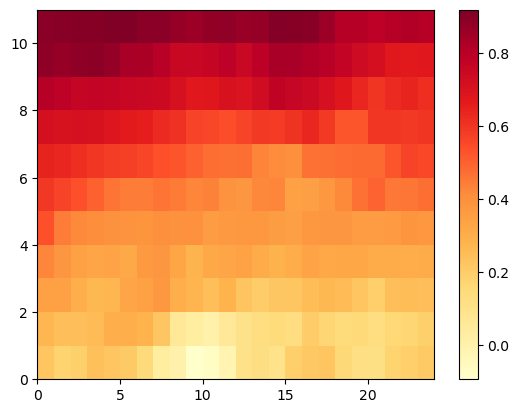

In [41]:
tcont = plt.pcolormesh(np.flipud(temp_contribution), cmap='YlOrRd')
plt.colorbar(tcont)

plt.show()

In [23]:
# For games its either we are playing or not, could do a very tight gradient where the parameter lies, say 25 is the yes no mark have like 30 be 70 percent
# Start with all contributions set to 0
WBGT_contribution = np.zeros_like(WBGT)


mask = (WBGT >= 90) 
WBGT_contribution[mask] = 1.0


mask = (WBGT > 32) & (WBGT <=89)
WBGT_contribution[mask] = 0

 #T <= 32 : contribution = 1
mask = WBGT <= 32
WBGT_contribution[mask] = 1.0

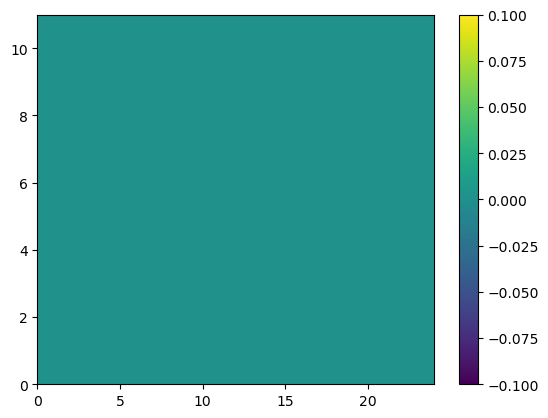

In [36]:
WBGTcont = plt.pcolormesh(np.flipud(WBGT_contribution))
plt.colorbar(WBGTcont)

plt.show()

In [25]:
# For games its either we are playing or not, could do a very tight gradient where the parameter lies, say 25 is the yes no mark have like 30 be 70 percent
# Start with all contributions set to 0
wind_contribution = np.zeros_like(wind_gust_2d)

# 80 <= T < 90 : linear increase from 0 to 1
mask = (wind_gust_2d >= 25) & (wind_gust_2d < 50)
wind_contribution[mask] = (wind_gust_2d[mask] - 25) / 20 #giving us the where temp_contribution is true and which grid point that in then taking that number and -60 and /20 to then replace it with a new value inside that grid point

# 90 <= wind  or T<=32: contribution = 1
mask = (wind_gust_2d >= 50) 
wind_contribution[mask] = 1.0

mask = (wind_gust_2d < 25 )
wind_contribution[mask] = 0

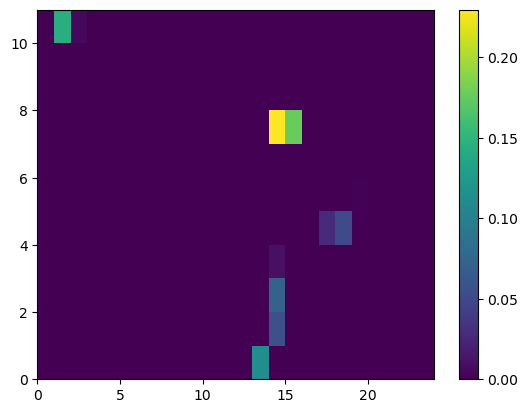

In [34]:
wcont = plt.pcolormesh(np.flipud(wind_contribution))
plt.colorbar(wcont)

plt.show()

In [27]:
accum_precip = precip[5, :, :] - precip[1, :, :]


In [28]:
precip_contribution = np.zeros_like(accum_precip)


mask = (accum_precip >= 0.20) & (accum_precip < 0.9)
precip_contribution[mask] = (accum_precip[mask] - 0.20) / 20 #giving us the where temp_contribution is true and which grid point that in then taking that number and -60 and /20 to then replace it with a new value inside that grid point

# 90 <= T  or T<=32: contribution = 1
mask = (accum_precip >= 1.0) 
precip_contribution[mask] = 1.0


 #T <= 32 : contribution = 1
mask = accum_precip < 0.20
precip_contribution[mask] = 0

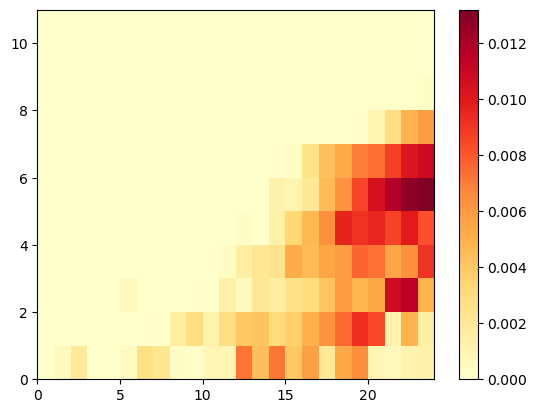

In [40]:
pcont = plt.pcolormesh(np.flipud(precip_contribution), cmap= 'YlOrRd')
plt.colorbar(pcont)

plt.show()

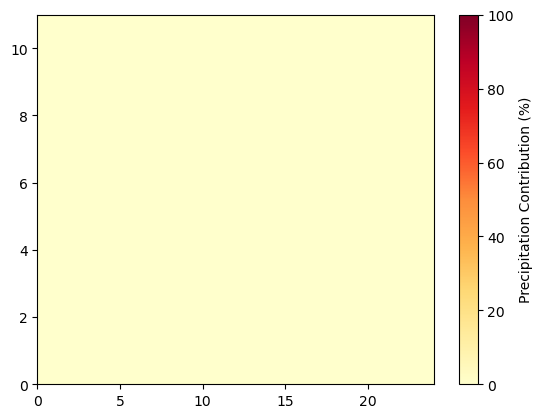

In [39]:
pcont2 = plt.pcolormesh(np.flipud(precip_contribution), cmap='YlOrRd', vmin=0, vmax=100)
cbar = plt.colorbar(pcont2)
cbar.set_ticks([0, 20, 40, 60, 80, 100])
cbar.set_label('Precipitation Contribution (%)')
plt.show()

In [30]:
PUI = (temp_contribution*0.3 + wind_contribution*0.3 + precip_contribution*0.2 + WBGT_contribution*0.2)*100 #formula for each contribution of hazards
PUI 

array([[26.908821  , 31.380527  , 27.215427  , 27.119759  , 27.499443  ,
        27.541634  , 26.782257  , 26.866632  , 26.02288   , 25.72757   ,
        26.318192  , 26.444757  , 25.980694  , 26.149446  , 27.246317  ,
        27.07757   , 26.993195  , 25.72757   , 24.208818  , 24.04007   ,
        23.618195  , 23.99788   , 24.461945  , 24.082256  ],
       [26.571318  , 26.107254  , 26.486946  , 26.655695  , 26.149446  ,
        25.010384  , 24.84163   , 23.871317  , 22.64788   , 22.774445  ,
        23.027567  , 23.618195  , 22.563507  , 23.66038   , 25.052568  ,
        24.968195  , 24.54632   , 23.955696  , 23.111946  , 22.099443  ,
        21.424446  , 20.28538   , 20.15882   , 20.28538   ],
       [24.04007   , 23.576006  , 23.027567  , 23.069756  , 22.943193  ,
        22.732254  , 22.479134  , 22.268194  , 21.171318  , 20.201006  ,
        20.411945  , 21.129131  , 21.00257   , 22.057257  , 23.407257  ,
        22.85882   , 22.35257   , 21.29788   , 20.411945  , 18.97757   ,
  

In [1]:
time=[0,12]
for i in time:
    tempf2d=(ds2['t2m'][i,:,:].values-273.15)*(9/5)+32
    dewf2d=(ds2['d2m'][i,:,:].values-273.15)*(9/5)+32
    windgust2d=ds2['fg10'][i,:,:].values*2.2369
    if i>0:
        accum_precip=ds2['tp'][i,:,:].values -ds2['tp'][i-1,:,:].values
    else:
        accum_precip=ds2['tp'][i,:,:].values

    RH=calc_rh(tempf2d,dewf2d)
    Tw=wet_bulb_temp(tempf2d,RH)
    WBGT=wbgt_calc(tempf2d,Tw)

    temp_c = np.zeros_like(tempf2d)
    temp_c[(tempf2d >= 80) & (tempf2d < 90)] = (tempf2d[(tempf2d >= 80) & (tempf2d < 90)] - 80)/20
    temp_c[tempf2d >= 90] = 1
    temp_c[temp_f_2d <= 32] = 1

    WBGT_c = np.zeros_like(WBGT)
    WBGT_c[WBGT >= 90] = 1
    WBGT_c[WBGT <= 32] = 1

    wind_c = np.zeros_like(windgust2d)
    wind_c[(windgust2d >= 25) & (windgust2d < 50)] = (windgust2d[(windgust2d >= 25) & (windgust2d < 50)] - 25)/20
    wind_c[windgust2d >= 50] = 1

    precip_c = np.zeros_like(accum_precip)
    precip_c[(accum_precip >= 0.20) & (accum_precip < 1.0)] = (accum_precip[(accum_precip >= 0.20) & (accum_precip < 1.0)] - 0.20) / (1.0 - 0.2)
    precip_c[accum_precip >= 1.0] = 1

    PUI = (temp_c*0.3 + wind_c*0.3 + precip_c*0.2 + WBGT_c*0.2)*100

NameError: name 'ds2' is not defined

In [ ]:
#ds.merge.2netcdf